# Customer Churn Prediction Models
This notebook implements **Logistic Regression** and **Random Forest** models to predict customer churn using the provided dataset.

## Phase 1: Data Loading & Preprocessing
First, we load the training and test datasets and preprocess them. 
Preprocessing includes:
- Mapping binary categorical variables ('International plan', 'Voice mail plan').
- Target encoding for the 'State' variable.
- Identifying and separating features and target matrices.
- Standard scaling numerical variables for the Logistic Regression model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.model_selection import GridSearchCV
from pathlib import Path

# Load datasets
train_path = Path('churn-train.csv')
test_path = Path('churn-test.csv')
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Preprocessing Function
def preprocess_data(df, is_train=True, scaler=None, mean_state=None):
    df = df.copy()
    
    # Binary variables
    for col in ['International plan', 'Voice mail plan']:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
        
    # Target variable
    if 'Churn' in df.columns:
        df['Churn'] = df['Churn'].astype(int)
        
    # Handle 'State' - Target encoding for simplicity
    if is_train:
        mean_state = df.groupby('State')['Churn'].mean()
        df['State_encoded'] = df['State'].map(mean_state)
    else:
        df['State_encoded'] = df['State'].map(mean_state).fillna(mean_state.mean())
        
    df = df.drop(['State'], axis=1)
    
    # Separate features and target
    X = df.drop('Churn', axis=1)
    y = df['Churn']
    
    if is_train:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        return X_scaled, y, scaler, mean_state
    else:
        X_scaled = scaler.transform(X)
        return X_scaled, y

# Apply Preprocessing
X_train, y_train, scaler, mean_state = preprocess_data(train_data, is_train=True)
X_test, y_test = preprocess_data(test_data, is_train=False, scaler=scaler, mean_state=mean_state)
feature_names = train_data.drop(['Churn', 'State'], axis=1).columns.tolist() + ['State_encoded']

## Phase 2: Logistic Regression
We train a Logistic Regression model, evaluate its performance using accuracy, precision, and recall, and interpret the feature coefficients / odds ratios. We also plot the ROC Curve.

In [2]:
# Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.4f}")

Accuracy: 0.8606
Precision: 0.5227
Recall: 0.2421


In [3]:
# Coefficients and Odds Ratios
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)
coef_df

,Feature,Coefficient,Odds Ratio
17,Customer service calls,0.678864,1.971637
2,International plan,0.645745,1.907407
18,State_encoded,0.509074,1.663749
4,Number vmail messages,0.407758,1.503444
7,Total day charge,0.339762,1.404613
5,Total day minutes,0.339600,1.404386
8,Total eve minutes,0.150252,1.162127
10,Total eve charge,0.149113,1.160804
16,Total intl charge,0.130295,1.139164
14,Total intl minutes,0.125661,1.133898


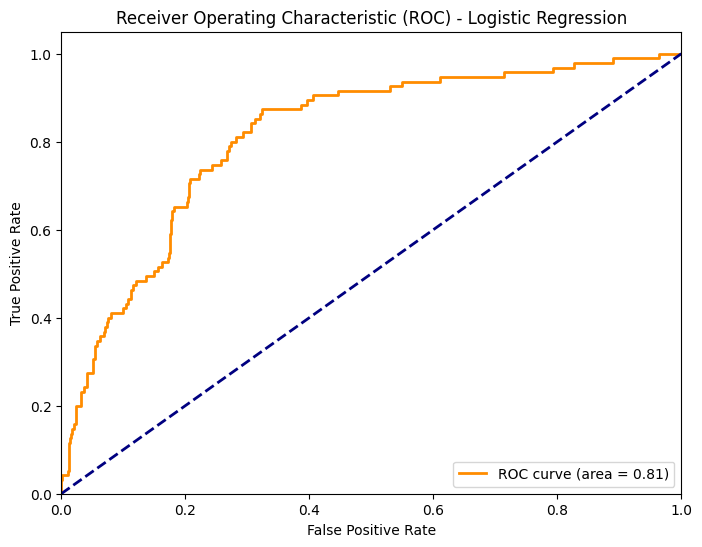

In [4]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

## Phase 3: Random Forest Classifier
Now, we train a Random Forest classifier. We will perform basic hyperparameter tuning via GridSearchCV and evaluate the model using Accuracy, Precision, Recall, and F1-score. Finally, we analyze the most important features driving customer churn.

In [5]:
# Train Random Forest with GridSearchCV
rf = RandomForestClassifier(random_state=42)

# Hyperparameter Tuning (using a small grid for faster execution)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Predictions
y_pred_rf = best_rf.predict(X_test)

print(f"Random Forest Metrics on Test Set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Metrics on Test Set:
Accuracy: 0.9580
Precision: 1.0000
Recall: 0.7053
F1-Score: 0.8272


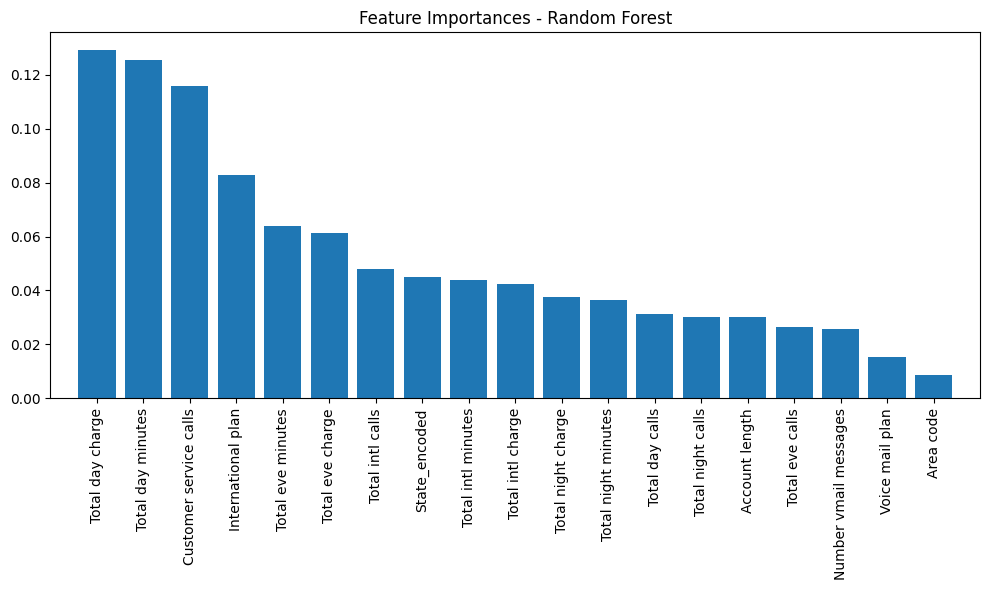

In [7]:
# Feature Importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Random Forest")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()